In [39]:
pip install shapely


Note: you may need to restart the kernel to use updated packages.


In [40]:
pip install geopandas


Note: you may need to restart the kernel to use updated packages.


In [41]:
pip install cartiflette

Note: you may need to restart the kernel to use updated packages.


# Préparation des données IRVE

## Objectif

Construire un jeu de données agrégé par code géographique à partir de la base nationale des bornes de recharge électrique (IRVE), afin d'expliquer ou prédire le taux de véhicules électriques local.

In [42]:
# import et chargement des données

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_irve = pd.read_csv(
    "https://www.data.gouv.fr/api/1/datasets/r/eb76d20a-8501-400e-b336-d85724de5435"
)

print("Shape :", df_irve.shape)
df_irve.sample(5)

/tmp/ipykernel_54250/2858965990.py:7: DtypeWarning: Columns (12,18,19,20,21,22,24,25,29,33) have mixed types. Specify dtype option on import or set low_memory=False.
  df_irve = pd.read_csv(


Shape : (213699, 52)


,nom_amenageur,siren_amenageur,contact_amenageur,nom_operateur,contact_operateur,telephone_operateur,nom_enseigne,id_station_itinerance,id_station_local,nom_station,...,datagouv_resource_id,datagouv_organization_or_owner,created_at,consolidated_longitude,consolidated_latitude,consolidated_code_postal,consolidated_commune,consolidated_is_lon_lat_correct,consolidated_is_code_insee_verified,consolidated_is_code_insee_modified
5551,DRIVECO,NaN,support@driveco.com,DRIVECO Partner Network,support@driveco.com,NaN,DRIVECO,FRAIRPAIRBUS78990P1,NaN,Airbus ADS - Elancourt - powered by DRIVECO,...,775dd5a9-c0e4-4bb7-8995-f4b5a4148836,driveco,2026-01-30T10:47:39.688000+00:00,1.971874,48.798097,78990.0,Élancourt,True,True,False
125695,Power Dot France,891118473.0,hello@powerdot.fr,Power Dot France,hello@powerdot.fr,tel:+33-1-76-31-06-84,Power Dot France,FRPD1PITMMSC,NaN,Intermarché - Massiac,...,8bb0a6e2-1016-42ba-aaee-f72f55c82e9f,qualicharge,2025-05-05T13:28:02.361000+00:00,3.199681,45.262366,15500.0,Massiac,True,True,False
5818,Allego,842718512.0,mathieu.laneelle@allego.eu,Allego,fabien.lepeytre@allego.eu,tel:+33-6-22-53-03-38,Allego - Intermarché Montpellier,FRALLPGO002051,FRALLPGO002051,Allego - Intermarché Montpellier,...,8bb0a6e2-1016-42ba-aaee-f72f55c82e9f,qualicharge,2025-05-05T13:28:02.361000+00:00,3.888870,43.588540,NaN,Montpellier,True,True,False
207735,SHEET ANCHOR ALPHA,797424959.0,hugues.bousquet@proudreed.com,WAAT Umbrella-Copro,exploitation@waat.fr,tel:+33-1-23-45-67-89,WAAT - PROUDREED,FRWA2P631993,FR*WA2*631993,PROUDREED_LONS_DC,...,8bb0a6e2-1016-42ba-aaee-f72f55c82e9f,qualicharge,2025-05-05T13:28:02.361000+00:00,-0.398595,43.321772,64140.0,Lons,True,True,False
176741,La borne bleue,NaN,NaN,Bouygues Energies & Services,support@alizecharge.fr,0805021480,La borne bleue,FRSIPE94067007,NaN,SAINT-MANDÉ - Jeanne d'arc,...,5f29737c-5393-46f9-8140-2509992adc7a,alize,2025-03-17T08:58:10.352000+00:00,2.417958,48.840810,94160.0,Saint-Mandé,True,True,False


La base contient 212 234 lignes et 52 variables.

Chaque ligne correspond à une borne / point de recharge déclaré.

## Enrichissement du code géographique

L'objectif final étant une modélisation territoriale, chaque borne doit être rattachée à une zone géographique.

In [43]:
from src.preparation_data import (
    nettoyer_code_insee,
    creer_gdf_irve,
    charger_communes,
    joindre_communes,
    ajouter_codes_geo
)

df_irve["code_insee_commune"] = df_irve["code_insee_commune"].apply(nettoyer_code_insee)

gdf_irve = creer_gdf_irve(df_irve, "consolidated_longitude", "consolidated_latitude")
gdf_communes = charger_communes()
gdf_result = joindre_communes(gdf_irve, gdf_communes)

df_irve = ajouter_codes_geo(df_irve, gdf_result)

There was an error while reading the file from the URL: https://minio.lab.sspcloud.fr/projet-cartiflette/production/provider=IGN/dataset_family=ADMINEXPRESS/source=EXPRESS-COG-CARTO-TERRITOIRE/year=2022/administrative_level=COMMUNE/crs=4326/DEPARTEMENT=20/vectorfile_format=geojson/territory=metropole/simplification=0/raw.geojson
Error message: '/vsimem/pyogrio_932e2609cba947e8a57f0033935b0387' not recognized as being in a supported file format.; It might help to specify the correct driver explicitly by prefixing the file path with '<DRIVER>:', e.g. 'CSV:path'.


## Sélection initiale des variables

Les variables ont été retenues selon leur potentiel explicatif :
- attractivité du réseau
- accessibilité
- performance technique
- structure concurrentielle

In [44]:
list(df_irve.columns)

['nom_amenageur',
 'siren_amenageur',
 'contact_amenageur',
 'nom_operateur',
 'contact_operateur',
 'telephone_operateur',
 'nom_enseigne',
 'id_station_itinerance',
 'id_station_local',
 'nom_station',
 'implantation_station',
 'adresse_station',
 'code_insee_commune',
 'coordonneesXY',
 'nbre_pdc',
 'id_pdc_itinerance',
 'id_pdc_local',
 'puissance_nominale',
 'prise_type_ef',
 'prise_type_2',
 'prise_type_combo_ccs',
 'prise_type_chademo',
 'prise_type_autre',
 'gratuit',
 'paiement_acte',
 'paiement_cb',
 'paiement_autre',
 'tarification',
 'condition_acces',
 'reservation',
 'horaires',
 'accessibilite_pmr',
 'restriction_gabarit',
 'station_deux_roues',
 'raccordement',
 'num_pdl',
 'date_mise_en_service',
 'observations',
 'date_maj',
 'cable_t2_attache',
 'last_modified',
 'datagouv_dataset_id',
 'datagouv_resource_id',
 'datagouv_organization_or_owner',
 'created_at',
 'consolidated_longitude',
 'consolidated_latitude',
 'consolidated_code_postal',
 'consolidated_commune',
 '

Après un leger tri des variables disponibles, on choisit de s'interresser aux suivantes :

In [45]:
var_interet = [
    "code_geo_total",
    "nom_operateur",
    "implantation_station",
    "nbre_pdc",
    "puissance_nominale",
    "prise_type_ef",
    "prise_type_2",
    "prise_type_combo_ccs",
    "prise_type_chademo",
    "prise_type_autre",
    "cable_t2_attache",
    "gratuit",
    "paiement_acte",
    "paiement_cb",
    "paiement_autre",
    "tarification",
    "condition_acces",
    "reservation",
    "horaires",
    "created_at"
]

df_filtre = df_irve[var_interet].copy()

## Vérification des types

Les types de données fournis par la source ne sont pas respectés dans les données brutes. Plusieurs variables booléennes et temporelles sont encodées en texte (object), nécessitant une étape de conversion avant analyse.

In [46]:
df_filtre.dtypes

code_geo_total           object
nom_operateur            object
implantation_station     object
nbre_pdc                  int64
puissance_nominale      float64
prise_type_ef            object
prise_type_2             object
prise_type_combo_ccs     object
prise_type_chademo       object
prise_type_autre         object
cable_t2_attache         object
gratuit                  object
paiement_acte            object
paiement_cb              object
paiement_autre           object
tarification             object
condition_acces          object
reservation              object
horaires                 object
created_at               object
dtype: object

Booléens

In [47]:
cols_bool = [
    'prise_type_ef',
    'prise_type_2',
    'prise_type_combo_ccs',
    'prise_type_chademo',
    'prise_type_autre',
    'cable_t2_attache',
    'gratuit',
    'paiement_acte',
    'paiement_cb',
    'paiement_autre',
    'reservation'
]

In [48]:
for col in cols_bool:
    print(f"\n----- {col} -----")
    print(df_filtre[col].value_counts(dropna=False))


----- prise_type_ef -----
prise_type_ef
False    74806
False    49100
false    26497
True     23498
True     17242
true     15486
FALSE     4273
0         1554
TRUE      1021
1          222
Name: count, dtype: int64

----- prise_type_2 -----
prise_type_2
True     53884
True     48362
False    44420
true     29453
False    18001
false    12513
TRUE      3717
FALSE     1572
1         1550
0          227
Name: count, dtype: int64

----- prise_type_combo_ccs -----
prise_type_combo_ccs
False    54623
False    49058
false    34975
True     32862
True     20636
true     14212
FALSE     3265
TRUE      2289
0         1600
1          179
Name: count, dtype: int64

----- prise_type_chademo -----
prise_type_chademo
False    78530
False    71077
false    46142
FALSE     4330
True      4156
True      3390
true      3071
0         1727
TRUE      1224
1           52
Name: count, dtype: int64

----- prise_type_autre -----
prise_type_autre
False    80900
False    73752
false    48455
FALSE     4984
0  

In [49]:
# Récupérer toutes les valeurs uniques
valeurs_uniques = set()

for col in cols_bool:
    valeurs_uniques.update(df_filtre[col].unique())

# Afficher le résultat
print(valeurs_uniques)

{False, True, 'True', '1', '0', 'False', 'TRUE', 'false', nan, 'true', 'FALSE'}


In [50]:
mapping = {
    'true': True,
    'false': False,
    '1': True,
    '0': False
}

for col in cols_bool:
    df_filtre[col] = (
        df_filtre[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(mapping)
        .astype("boolean")
    )

for col in cols_bool:
    print(f"{col} :", df_filtre[col].unique())

prise_type_ef : <BooleanArray>
[False, True]
Length: 2, dtype: boolean
prise_type_2 : <BooleanArray>
[True, False]
Length: 2, dtype: boolean
prise_type_combo_ccs : <BooleanArray>
[False, True]
Length: 2, dtype: boolean
prise_type_chademo : <BooleanArray>
[False, True]
Length: 2, dtype: boolean
prise_type_autre : <BooleanArray>
[False, True]
Length: 2, dtype: boolean
cable_t2_attache : <BooleanArray>
[False, <NA>, True]
Length: 3, dtype: boolean
gratuit : <BooleanArray>
[False, True, <NA>]
Length: 3, dtype: boolean
paiement_acte : <BooleanArray>
[True, False]
Length: 2, dtype: boolean
paiement_cb : <BooleanArray>
[True, False, <NA>]
Length: 3, dtype: boolean
paiement_autre : <BooleanArray>
[<NA>, True, False]
Length: 3, dtype: boolean
reservation : <BooleanArray>
[False, True]
Length: 2, dtype: boolean


Date

In [51]:
df_filtre['created_at'] = pd.to_datetime(df_filtre['created_at'])

String / catégories

In [52]:
cols_str = [
    'nom_amenageur',
    'nom_operateur',
    'nom_enseigne',
    'id_station_local',
    'id_pdc_itinerance',
    'id_station_itinerance',
    'id_pdc_local',
    'implantation_station',
    'tarification',
    'condition_acces',
    'horaires'
]

for col in cols_str:
    df_filtre[col] = (
        df_filtre[col]
        .astype("string")
    )

KeyError: 'nom_amenageur'

Verification des types

In [ ]:
df_filtre.dtypes

In [ ]:
df_filtre.describe(include='string[python]')

'implantation_station' et 'condition_acces' ont peu de valeurs uniques. On les convertit donc en 'category'

In [ ]:
df_filtre['implantation_station'] = df_filtre['implantation_station'].astype('category')
df_filtre['condition_acces'] = df_filtre['condition_acces'].astype('category')

finalement :

In [ ]:
df_filtre.describe(include='all')

## Analyse des valeurs manquantes

In [ ]:
na = (
    df_filtre.isna()
    .sum()
    .sort_values(ascending=False)
)

na_pct = (na / len(df_filtre) * 100).round(2)

pd.DataFrame({
    "nb_manquants": na,
    "%": na_pct
}).head(10)

Les colonnes avec BEAUCOUP de valeurs manquantes :

| Colonne            | Nb manquants | Interprétation     |
| ------------------ | ------------ | ------------------ |
| `cable_t2_attache` | 102 007      | très problématique |
| `gratuit`          | 34 365       | moyen              |
| `paiement_autre`   | 39 806       | moyen              |
| `paiement_cb`      | 15 944       | acceptable         |
| `nom_operateur`    | 3 992        | faible             |


## Variables écartées

Certaines variables ont été retirées avant modélisation.

#### Analyses univariées utiles

In [ ]:
# paiement_acte
df_filtre["paiement_acte"].value_counts(normalize=True) * 100

paiement_acte
True     80.282079
False    19.717921
Name: proportion, dtype: Float64

Variable très déséquilibrée, faible pouvoir discriminant.

In [ ]:
# condition_acces

df_filtre["condition_acces"] = df_filtre["condition_acces"].replace({
    "Accčs libre": "Accès libre",
    "Accs libre": "Accès libre",
    "Acc¸s libre": "Accès libre",
    "AccĂ¨s libre": "Accès libre"
})

df_filtre["condition_acces"].value_counts(normalize=True) * 100

86% des observations correspondent à "Accès libre".

In [ ]:
# created_at
df_filtre["annee"] = df_filtre["created_at"].dt.year
df_filtre["annee"].value_counts().sort_index().plot()
plt.show()

Variable davantage administrative que structurelle.

In [ ]:
# tarification
print(df_filtre["tarification"].value_counts(dropna=False).head(15))
# nombre de modalités uniques
print("Nb modalités uniques :", df_filtre["tarification"].nunique())

Les valeurs sont trop diverses ce qui rend la variables difficile à traiter.

In [ ]:
# reservation
print(df_filtre["reservation"].value_counts(normalize=True, dropna=False) * 100)

Cette variable n'est pas assez variable (80% d'une même modalité). Elle n'apporte pas beaucoup d'information donc on décide de la supprimer.

In [ ]:
# horaires
print(df_filtre["horaires"].describe())
print(df_filtre["horaires"].value_counts(dropna=False).head(15))
print("Nb modalités uniques :", df_filtre["horaires"].nunique())

Les valeurs sont trop diverses ce qui rend la variables difficile à traiter.

| Variable         | Raison                      |
| ---------------- | --------------------------- |
| cable_t2_attache | ~48% manquants              |
| horaires         | texte libre très hétérogène |
| tarification     | texte libre très hétérogène           |
| prise_type_autre | peu informative             |
| paiement_acte    | quasi constante             |
| condition_acces  | très déséquilibrée          |
| reservation      | faible variabilité          |
| created_at       | date administrative         |
| nom_amenageur| trop de modalités   |
| nom_enseigne| trop de modalités   |
| id_station_*   |  aucune valeur prédictive  |
| id_pdc_*  | aucune valeur prédictive  |


## Variables retenues pour la modélisation

In [ ]:
vars_finales = ['nom_operateur',
               'implantation_station',
               'nbre_pdc',
               'puissance_nominale',
               'prise_type_ef',
               'prise_type_2',
               'prise_type_combo_ccs',
               'prise_type_chademo',
               'gratuit',
               'paiement_cb',
               'paiement_autre']

## Agrégation territoriale

Une ligne finale = un code géographique.

| Variable finale   | Construction      |
| ----------------- | ----------------- |
| total_pdc         | somme             |
| puissance_moyenne | moyenne           |
| puissance_max     | max               |
| nb_operateurs     | nunique           |
| top_operateur     | mode              |
| pct_type_2        | moyenne booléenne |
| pct_gratuit       | moyenne booléenne |
| part_voirie       | dummies + moyenne |


Le jeu de données final est désormais prêt à être fusionné avec les données socio-économiques locales afin de modéliser le taux de véhicules électriques.

# Brouillon

### puissance_nominale
faire des analyse uni pour bien comprendre les puissances des bornes et  créez une variable "Nombre de bornes ultra-rapides" (> 50 kW)

In [ ]:
# ------------------------------------------------------------
# 6. created_at
# ------------------------------------------------------------

print("===== created_at =====")
print(df_filtre["created_at"].describe())

# année création
df_filtre["annee_creation"] = df_filtre["created_at"].dt.year

print(df_filtre["annee_creation"].value_counts().sort_index())

df_filtre["annee_creation"].value_counts().sort_index().plot(kind="line", marker="o")
plt.title("Nombre de bornes par année de création")
plt.xlabel("Année")
plt.ylabel("Nombre")
plt.show()


# ancienneté en années
today = pd.Timestamp.today(tz="UTC")
df_filtre["anciennete"] = (today - df_filtre["created_at"]).dt.days / 365

print(df_filtre["anciennete"].describe())

df_filtre["anciennete"].hist(bins=30)
plt.title("Distribution ancienneté des bornes")
plt.xlabel("Ancienneté (années)")
plt.show()

revoir le tableau des var retenues et celui des agrégation territoriale.

1. Variables d'identification et d'acteurs
Ces variables permettent de mesurer la diversité et le type d'acteurs présents.

Représentent les entités responsables de l'installation et de l'exploitation.
Usage final : Calculez le nombre d'opérateurs différents par commune. Plus il y a d'acteurs, plus le réseau est compétitif et attractif.
['nom_amenageur',
 'nom_operateur',
 'nom_enseigne']


2. Variables de localisation et d'infrastructure

Identifiants uniques de la station (un regroupement de plusieurs bornes).
Usage final : Comptez le nombre de stations par commune (plutôt que le nombre de points de charge) pour mesurer le maillage territorial.
 'id_station_itinerance',
 'id_station_local',

Identifiants du point de charge précis.
'id_pdc_itinerance',
 'id_pdc_local',

Type de lieu (voirie, parking public, parking privé, etc.).
Usage final : Calculez la part des bornes en voirie (accessible 24/24) vs en parking.
 'implantation_station',

Nombre de points de charge sur la borne.
Usage final : À sommer par commune pour obtenir la capacité totale d'accueil.
 'nbre_pdc',


3. Puissance et Types de prises (Performance technique)
C'est le cœur de l'attractivité pour l'utilisateur.

Puissance délivrée (en kW).
Usage final : Calculez la puissance moyenne ou créez une variable "Nombre de bornes ultra-rapides" (> 50 kW).
 'puissance_nominale',

Indiquent les standards de recharge disponibles.
Usage final : Calculez le taux de compatibilité Combo CCS (standard européen pour la charge rapide). Une commune n'ayant que du Type EF (prises domestiques) est moins attractive.
 'prise_type_ef',
 'prise_type_2',
 'prise_type_combo_ccs',
 'prise_type_chademo',
 'prise_type_autre',
 'cable_t2_attache',


4. Services, Tarification et Accessibilité
Ces variables influencent directement le coût d'usage.

Indique si la recharge est gratuite.
Usage final : Taux de gratuité par commune. Un fort taux peut booster l'achat de VE locaux.
 'gratuit',

Modalités de paiement.
Usage final : Taux d'acceptation CB. Le paiement direct est un facteur clé de simplicité.
 'paiement_acte',
 'paiement_cb',
 'paiement_autre',
 'tarification',

Accessibilité de la borne.
Usage final : Créez une variable binaire sur la disponibilité 24h/24.
 'condition_acces',
 'reservation',
 'horaires',

Date de création de la fiche.
Usage final : Calculez l'ancienneté moyenne du réseau par commune.
 'created_at']

===== Statistiques =====
count    213699.000000
mean        103.547595
std         476.928148
min           0.000000
25%          22.000000
50%          22.000000
75%         120.000000
max       50000.000000
Name: puissance_nominale, dtype: float64
===== Top puissances =====
puissance_nominale
22.00     79005
7.40      12968
7.00      12577
150.00    12233
300.00    11901
50.00     10937
250.00     8181
22.08      7527
0.00       5109
100.00     4817
120.00     4432
200.00     4229
24.00      3969
180.00     3057
18.00      2889
3.70       2598
350.00     2282
400.00     2271
60.00      1894
7.36       1750
Name: count, dtype: int64


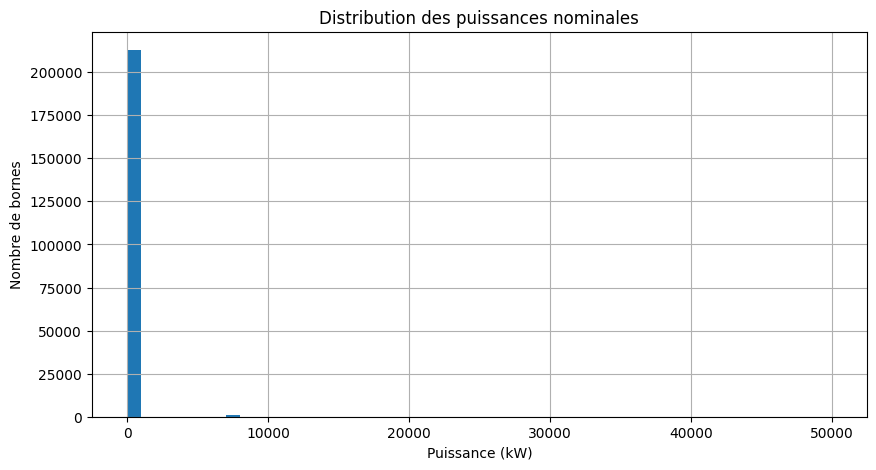

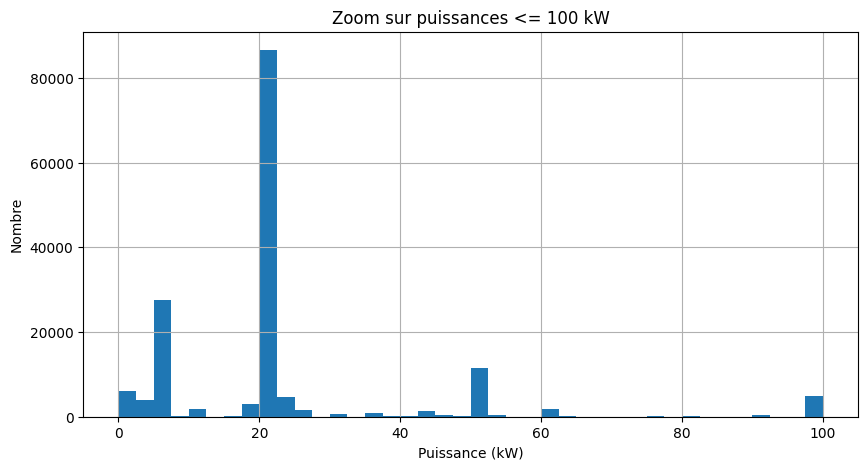

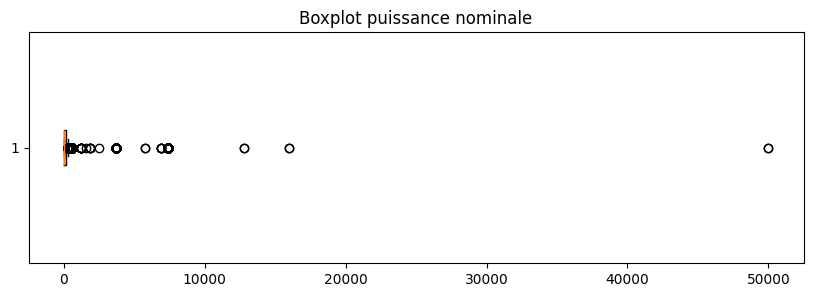

===== Quantiles =====
0.25     22.0
0.50     22.0
0.75    120.0
0.90    250.0
0.95    300.0
0.99    400.0
Name: puissance_nominale, dtype: float64
% bornes >= 7 kW : 95.18%
% bornes >= 22 kW : 79.82%
% bornes >= 43 kW : 35.60%
% bornes >= 50 kW : 34.70%
% bornes >= 100 kW : 27.88%
% bornes >= 150 kW : 23.37%


In [53]:
# ----------------------------
# Statistiques générales
# ----------------------------
print("===== Statistiques =====")
print(df_filtre["puissance_nominale"].describe())

# ----------------------------
# Valeurs les plus fréquentes
# ----------------------------
print("===== Top puissances =====")
print(df_filtre["puissance_nominale"].value_counts().head(20))

# ----------------------------
# Histogramme global
# ----------------------------
plt.figure(figsize=(10,5))
df_filtre["puissance_nominale"].hist(bins=50)
plt.title("Distribution des puissances nominales")
plt.xlabel("Puissance (kW)")
plt.ylabel("Nombre de bornes")
plt.show()

# ----------------------------
# Zoom sur faibles puissances
# ----------------------------
plt.figure(figsize=(10,5))
df_filtre[df_filtre["puissance_nominale"] <= 100]["puissance_nominale"].hist(bins=40)
plt.title("Zoom sur puissances <= 100 kW")
plt.xlabel("Puissance (kW)")
plt.ylabel("Nombre")
plt.show()

# ----------------------------
# Boxplot
# ----------------------------
plt.figure(figsize=(10,3))
plt.boxplot(df_filtre["puissance_nominale"].dropna(), vert=False)
plt.title("Boxplot puissance nominale")
plt.show()

# ----------------------------
# Quantiles utiles
# ----------------------------
print("===== Quantiles =====")
print(df_filtre["puissance_nominale"].quantile([0.25,0.5,0.75,0.90,0.95,0.99]))

# ----------------------------
# Parts selon seuils métier
# ----------------------------
for seuil in [7, 22, 43, 50, 100, 150]:
    pct = (df_filtre["puissance_nominale"] >= seuil).mean() * 100
    print(f"% bornes >= {seuil} kW : {pct:.2f}%")

Une borne de recharge est considérée comme rapide lorsqu'elle est capable de proposer une puissance supérieure à 43 kW.